# Lab 3 Data Processing

### 1. Import the libraries

In [24]:
# import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


Import the data set

In [25]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/cxnner05/.cache/kagglehub/datasets/iammustafatz/diabetes-prediction-dataset/versions/1


## 2. Load the dataset

Read the data, get information about the dataset

In [26]:
df = pd.read_csv(f"{path}/diabetes_prediction_dataset.csv")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


All of the code are non null, and seems to have the correct data type. Try to read the first parts of the data

In [28]:
df.head(40)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


Try doing unique values for each column to see if there are any anomalies

In [29]:

for column in df.columns:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"Unique values ({len(unique_values)}): {unique_values}\n")

Column: gender
Unique values (3): ['Female' 'Male' 'Other']

Column: age
Unique values (102): [80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]

Column: hypertension
Unique values (2): [0 1]

Column: heart_disease
Unique values (2): [1 0]

Column: smoking_history
Unique values (6): ['never' 'No Info' 'current' 'former' 'ever' 'not current']

Column: bmi
Unique values (4247): [25.19 27.32 23.45 ... 59.42 44.39 60.52]

Column: HbA1c_lev

Based on the data, we have small set of unique values for some columns like hypertension, heart_disease, smoking_history, and diabetes. We can check the distribution of these values using value_counts() method. This will help us understand the frequency of each unique value in these columns.

In [30]:
for column in ['hypertension', 'heart_disease', 'smoking_history', 'diabetes']:
    value_counts = df[column].value_counts()
    print(f"Value counts for column:'{column}':")
    print(value_counts)
    print()

Value counts for column:'hypertension':
hypertension
0    92515
1     7485
Name: count, dtype: int64

Value counts for column:'heart_disease':
heart_disease
0    96058
1     3942
Name: count, dtype: int64

Value counts for column:'smoking_history':
smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

Value counts for column:'diabetes':
diabetes
0    91500
1     8500
Name: count, dtype: int64



## 3. Cleaning the Data Set

We can start by cleaning up the smoking_history column, grouping unknown or no values together.

In [ ]:
# We can create a new columns smoking_status to group unknown and never smoked together
def clean_smoking_history(value):
    match value:
        case 'current':
            return 'current'
        case 'former' | 'ever' | 'not current':
            return 'former'
        default:
            return 'never'

## 4. Feature Engineering

We can start by creating columns from the existing columns

In [ ]:
# BMI Categories
df['BMI_Category'] = pd.cut(df['bmi'], 
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

# Age Groups
df['Age_Group'] = pd.cut(df['age'],
                         bins=[0, 18, 35, 50, 65, 100],
                         labels=['Child', 'Young Adult', 'Adult', 'Middle Age', 'Senior'])

# Risk Score (composite feature)

"""
Basis for Risk Score:

Age
- 35 - 44 years old: + 2 points
- 45 - 54 years: +4 points
- 55 - 64 years: +6 points
- 65+: +8 points

BMI:
- Overweight (25-30): +2 points
- Over 30 (Obese): +5 point

Blood Glucose Level:
- 100 - 125 mg/dL (Prediabetes): +3 points

Hemoglobin A1c:
- 5.7% - 6.4% (Prediabetes): +10 points

Hypertension: +2 points
Smoking Group (Engineered Feature):
- current: +2 points
- former: +1 points
- never: 0 points

64 years: +8 points

Male: + 1 points
"""
df['Risk_Score'] = (df['hypertension'] * 2 + 
                    df['heart_disease'] * 3 + 
                    (df['bmi'] > 30).astype(int) + 
                    (df['blood_glucose_level'] > 140).astype(int))

# Smoking Status Binary
df['Is_Smoker'] = df['smoking_history'].apply(
    lambda x: 1 if x in ['smoked', 'not_current'] else 0
)

5. Visualize the data

Group the age group and the risk score to see the distribution of risk score across different age groups

/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_37428/3622024307.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_data = df.groupby('Age_Group')['Risk_Score'].mean().reset_index()
/var/folders/pc/qpl83vwd53v_hm0hj90d3nz00000gn/T/ipykernel_37428/3622024307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Risk_Score', data=risk_data, palette='viridis')


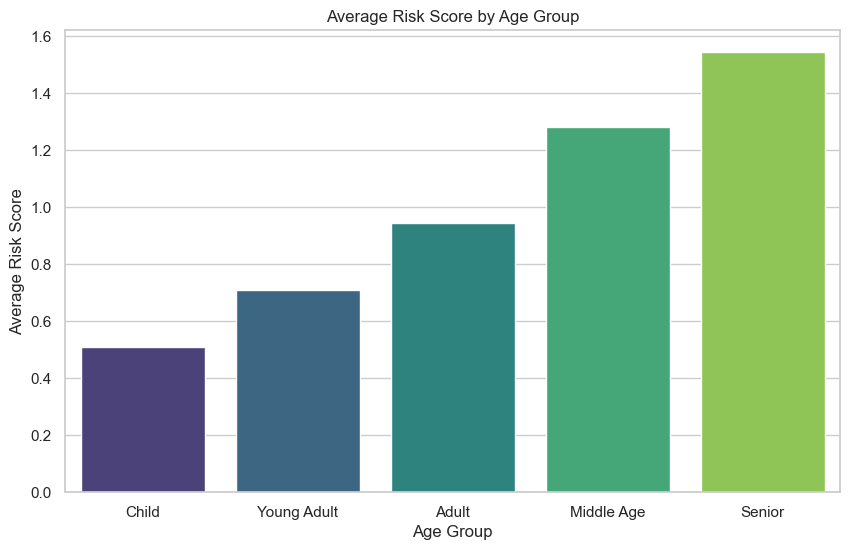

In [33]:
risk_data = df.groupby('Age_Group')['Risk_Score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Age_Group', y='Risk_Score', data=risk_data, palette='viridis')
plt.title('Average Risk Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Risk Score')
plt.show()

Optionally, we can transform the 